In [18]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from collections import defaultdict
from shutil import copy
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from tqdm.notebook import tqdm
import seaborn as sns
from collections import Counter

from glob import glob
import psi4
from helper_CC_ML_spacial import *

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

In [2]:
# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# 31 Features order in X, including t2
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']

In [3]:
basis_sets = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

In [4]:
molecules = ["water", "methanol", "ethylene", "ethane", "methane", "ammonia", "formaldehyde"]

In [5]:
random.seed(0)
all_sampled_files = []

all_files = sorted(glob(os.path.join("data", f"water*.xyz")))
sample_size = min(150, len(all_files))
sampled_files = random.sample(all_files, sample_size)
train = sampled_files[:100] # 100 train molecules
test = sampled_files[100:] # 50 test molecules

In [6]:
train

['data/water189.xyz',
 'data/water93.xyz',
 'data/water197.xyz',
 'data/water109.xyz',
 'data/water16.xyz',
 'data/water35.xyz',
 'data/water3.xyz',
 'data/water193.xyz',
 'data/water17.xyz',
 'data/water28.xyz',
 'data/water182.xyz',
 'data/water52.xyz',
 'data/water15.xyz',
 'data/water34.xyz',
 'data/water131.xyz',
 'data/water165.xyz',
 'data/water86.xyz',
 'data/water121.xyz',
 'data/water60.xyz',
 'data/water158.xyz',
 'data/water40.xyz',
 'data/water57.xyz',
 'data/water133.xyz',
 'data/water171.xyz',
 'data/water122.xyz',
 'data/water116.xyz',
 'data/water176.xyz',
 'data/water26.xyz',
 'data/water47.xyz',
 'data/water77.xyz',
 'data/water181.xyz',
 'data/water20.xyz',
 'data/water172.xyz',
 'data/water59.xyz',
 'data/water65.xyz',
 'data/water147.xyz',
 'data/water45.xyz',
 'data/water90.xyz',
 'data/water201.xyz',
 'data/water38.xyz',
 'data/water95.xyz',
 'data/water113.xyz',
 'data/water44.xyz',
 'data/water102.xyz',
 'data/water120.xyz',
 'data/water192.xyz',
 'data/water1

In [7]:
test

['data/water160.xyz',
 'data/water84.xyz',
 'data/water62.xyz',
 'data/water98.xyz',
 'data/water80.xyz',
 'data/water70.xyz',
 'data/water168.xyz',
 'data/water148.xyz',
 'data/water39.xyz',
 'data/water19.xyz',
 'data/water151.xyz',
 'data/water157.xyz',
 'data/water22.xyz',
 'data/water174.xyz',
 'data/water140.xyz',
 'data/water196.xyz',
 'data/water137.xyz',
 'data/water23.xyz',
 'data/water112.xyz',
 'data/water54.xyz',
 'data/water185.xyz',
 'data/water138.xyz',
 'data/water27.xyz',
 'data/water63.xyz',
 'data/water101.xyz',
 'data/water130.xyz',
 'data/water92.xyz',
 'data/water125.xyz',
 'data/water142.xyz',
 'data/water119.xyz',
 'data/water78.xyz',
 'data/water149.xyz',
 'data/water106.xyz',
 'data/water110.xyz',
 'data/water76.xyz',
 'data/water41.xyz',
 'data/water104.xyz',
 'data/water108.xyz',
 'data/water100.xyz',
 'data/water161.xyz',
 'data/water56.xyz',
 'data/water190.xyz',
 'data/water134.xyz',
 'data/water184.xyz',
 'data/water48.xyz',
 'data/water50.xyz',
 'data/

In [8]:
X_test_all = {}
y_test_all = {}
basis_sets = ["STO-3G"]
for basis in basis_sets:
    filenames = test.copy()
    t1 = time.time()
    print(basis)

    data_dict = {}
    for fn in filenames:
        struct = os.path.basename(fn)
        print(f"Processing {struct}")
        
        with open(fn,'r') as f:
            text=f.read()
        
        mol = psi4.geometry(text)
        
        psi4.core.clean()
        psi4.core.be_quiet()
        
        psi4.set_options({'basis': basis,
                          'scf_type': 'pk',
                          'reference': 'rohf',
                          'mp2_type': 'conv',
                          'e_convergence': 1e-8,
                          'd_convergence': 1e-8})

        try:
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A = HelperCCEnergy(mol, rhf_e, scf_wfn, freeze_core=False)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy()                                   # exact CCSD energy

            data = pd.DataFrame(np.array([getattr(A, attr).flatten() for attr in properties]).T, columns=properties)
            data_dict[struct.split('_')[0]] = data

        except Exception as e:
            print(f"Molecule with filename {fn} failed: {e}")
            pass   

    X_test_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
    y_test_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        
    splits = {
        'X_test': X_test_all[basis],
        'y_test': y_test_all[basis]
    }
    
    joblib.dump(splits, f"water_out/{basis}_test_data_splits.pkl")
    t2 = time.time()

    print(f"Time taken for {basis}: {t2-t1} seconds \n")

STO-3G
Processing water160.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.165 seconds.

CCSD Iteration   0: CCSD correlation = -0.034939300303044   dE =  3.49393E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034939300303044   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.009 seconds!
CCSD Iteration   0: CCSD correlation = -0.034939300303044   dE =  3.49393E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044234777738299   dE = -9.29548E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047131565832642   dE = -2.89679E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048690563634790   dE = -1.55900E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048806418191053   dE = -1.15855E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048813868675304   dE = -7.45048E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048811700649557   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.334 seconds.

CCSD Iteration   0: CCSD correlation = -0.034853190220114   dE =  3.48532E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034853190220114   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034853190220114   dE =  3.48532E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044112278142547   dE = -9.25909E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046992640534825   dE = -2.88036E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048538307033019   dE = -1.54567E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048652369945633   dE = -1.14063E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048659631902540   dE = -7.26196E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048657508423369   d

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.165 seconds.

CCSD Iteration   0: CCSD correlation = -0.034867925211674   dE =  3.48679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034867925211674   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034867925211674   dE =  3.48679E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044131005561924   dE = -9.26308E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047012752785776   dE = -2.88175E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048559343182540   dE = -1.54659E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048673482931023   dE = -1.14140E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048680751481202   dE = -7.26855E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048678626229419   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.178 seconds.

CCSD Iteration   0: CCSD correlation = -0.034965733473580   dE =  3.49657E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034965733473580   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034965733473580   dE =  3.49657E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044259441916776   dE = -9.29371E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047153012829021   dE = -2.89357E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048708237843944   dE = -1.55523E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048823309900267   dE = -1.15072E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048830669122700   dE = -7.35922E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048828521375140   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.232 seconds.

CCSD Iteration   0: CCSD correlation = -0.034856324838380   dE =  3.48563E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034856324838380   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034856324838380   dE =  3.48563E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044113951582944   dE = -9.25763E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046993138787893   dE = -2.87919E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048537608518958   dE = -1.54447E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048651454053485   dE = -1.13846E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048658691485515   dE = -7.23743E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048656573593033   d

In [9]:
n_list = [10, 20, 40, 60, 80, 100]
X_train_all = {}
y_train_all = {}

for basis in basis_sets: 
    for n in n_list:
        filenames = train[:n]
        t1 = time.time()
        
        print(f"{basis} Basis, N = {n} training molecules")
        print(f"Training molecules: {filenames}")

        # get training molecule
        data_dict = {}
        for fn in filenames:
            struct = os.path.basename(fn)
            print(f"Processing {struct}")
            
            with open(fn,'r') as f:
                text=f.read()
            
            mol = psi4.geometry(text)
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            try:
                
                rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
                
                A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)
    
    
                MP2T2=A.t2start
                A.t1 = np.zeros((A.t1.shape))
                A.t2 = MP2T2
                
                MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
                CCSDE = A.compute_energy()                                   # exact CCSD energy
    
                data=pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
                data_dict[struct.split('_')[0]]=data
            except Exception as e:
                print(f"Molecule with filename {fn} failed: {e}")
                pass   

        X_train_all[basis] = np.vstack([df[top5].to_numpy() for df in data_dict.values()])
        y_train_all[basis] = np.concatenate([df["t2"].to_numpy().reshape(-1) for df in data_dict.values()])

        splits = {
            'X_train': X_train_all[basis],
            'y_train': y_train_all[basis]
        }
        
        joblib.dump(splits, f"water_out/{basis}_train_data_splits_{n}.pkl")

STO-3G Basis, N = 10 training molecules
Training molecules: ['data/water189.xyz', 'data/water93.xyz', 'data/water197.xyz', 'data/water109.xyz', 'data/water16.xyz', 'data/water35.xyz', 'data/water3.xyz', 'data/water193.xyz', 'data/water17.xyz', 'data/water28.xyz']
Processing water189.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.237 seconds.

CCSD Iteration   0: CCSD correlation = -0.034954131911621   dE =  3.49541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034954131911621   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034954131911621   dE =  3.49541E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044242288095043   dE = -9.28816E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047133235313116   dE = -2.89095E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048686276992882   dE = -1.55304E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048801043963605   dE = -1.14767E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048808370723042   dE = -7.32676E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048806230639865   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.139 seconds.

CCSD Iteration   0: CCSD correlation = -0.035015498743990   dE =  3.50155E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035015498743990   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035015498743990   dE =  3.50155E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044335373680565   dE = -9.31987E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047241722258427   dE = -2.90635E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048807791860173   dE = -1.56607E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048924431702209   dE = -1.16640E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048931960229674   dE = -7.52853E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048929773012823   d

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.492 seconds.

CCSD Iteration   0: CCSD correlation = -0.034940926482475   dE =  3.49409E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034940926482475   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034940926482475   dE =  3.49409E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044222988418504   dE = -9.28206E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047111094948037   dE = -2.88811E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048661792319772   dE = -1.55070E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048776235756254   dE = -1.14443E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048783528348981   dE = -7.29259E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048781396363159   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.329 seconds.

CCSD Iteration   0: CCSD correlation = -0.035055617782630   dE =  3.50556E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.035055617782630   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.035055617782630   dE =  3.50556E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044391274606579   dE = -9.33566E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047304540980145   dE = -2.91327E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048876141148471   dE = -1.57160E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048993506571913   dE = -1.17365E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.049001111446780   dE = -7.60487E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048998906229449   d

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.405 seconds.

CCSD Iteration   0: CCSD correlation = -0.034895244426887   dE =  3.48952E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034895244426887   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.034895244426887   dE =  3.48952E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044169850817929   dE = -9.27461E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047056793216316   dE = -2.88694E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048607592660112   dE = -1.55080E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048722294203859   dE = -1.14702E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048729621742394   dE = -7.32754E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048727482480723   d

In [11]:
import xgboost as xgb

In [73]:
n_list = [10, 20, 40, 60, 80, 100]
for basis in basis_sets:
    print("Basis: ", basis)
    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]
    
    for n in n_list:
        print("N:", n)
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

        X_train = data["X_train"]
        y_train = data["y_train"]
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        joblib.dump(model_pipeline, f"water_out/{basis}_model_{n}.pkl")

Basis:  STO-3G
N: 10
N: 10, MAE: 0.00022299919483440153, RMSE: 0.001189435105762187, R2: 0.9943805746670744
Finished training in 50.3227801322937 seconds 

N: 20
N: 20, MAE: 6.378155033806839e-05, RMSE: 0.0003531061198028177, R2: 0.9995047540995203
Finished training in 50.1479070186615 seconds 

N: 40
N: 40, MAE: 4.4372181588144506e-05, RMSE: 0.0003044276754916093, R2: 0.9996318891119261
Finished training in 53.39903664588928 seconds 

N: 60
N: 60, MAE: 3.537755544928466e-05, RMSE: 0.00021954331708392432, R2: 0.9998085519956889
Finished training in 78.65840101242065 seconds 

N: 80
N: 80, MAE: 3.6202879149707206e-05, RMSE: 0.00023636662023805865, R2: 0.9997780870274564
Finished training in 82.90473914146423 seconds 

N: 100
N: 100, MAE: 2.8858696087430257e-05, RMSE: 0.00020248186968979171, R2: 0.9998371519041002
Finished training in 62.541985511779785 seconds 



In [81]:
from sklearn.neighbors import KNeighborsRegressor

In [84]:
n_list = [10, 20, 40, 60, 80, 100]
for basis in basis_sets:
    print("Basis: ", basis)
    data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
    X_test = data["X_test"]
    y_test = data["y_test"]
    
    for n in n_list:
        print("N:", n)
        data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

        X_train = data["X_train"]
        y_train = data["y_train"]
         
        model = KNeighborsRegressor(n_neighbors=5)
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, RMSE: {rmse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        joblib.dump(model_pipeline, f"water_out/knn_{basis}_model_{n}.pkl")

Basis:  STO-3G
N: 10
N: 10, MAE: 2.6037164568608068e-05, RMSE: 9.045525637321754e-05, R2: 0.9999675003998405
Finished training in 0.0219571590423584 seconds 

N: 20
N: 20, MAE: 1.762680724703746e-05, RMSE: 7.635926181848823e-05, R2: 0.999976840251292
Finished training in 0.003632068634033203 seconds 

N: 40
N: 40, MAE: 1.1675071731702573e-05, RMSE: 5.93133049494213e-05, R2: 0.9999860261959966
Finished training in 0.006251096725463867 seconds 

N: 60
N: 60, MAE: 8.618245064488421e-06, RMSE: 4.524543824341376e-05, R2: 0.9999918686997384
Finished training in 0.00708317756652832 seconds 

N: 80
N: 80, MAE: 6.804888781297792e-06, RMSE: 3.856179611640391e-05, R2: 0.9999940935720796
Finished training in 0.00937795639038086 seconds 

N: 100
N: 100, MAE: 5.780753275955713e-06, RMSE: 3.584866487052849e-05, R2: 0.9999948954628193
Finished training in 0.011562585830688477 seconds 



In [ ]:
#########################################

In [15]:
filenames = test.copy()
filenames[:5]

['data/water160.xyz',
 'data/water84.xyz',
 'data/water62.xyz',
 'data/water98.xyz',
 'data/water80.xyz']

In [89]:
#basis_sets = ['STO-3G']

n_list = [10, 20, 40, 60, 80, 100] # iterating over N=10, 20, 40, 60, 80, 100 training molecules

mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")
        
        fn = f"water_out/knn_{basis}_model_{n}.pkl"
        model = joblib.load(fn)
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy() 
            

            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in top5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
            #mlE = A.compute_energy()                # exact CCSD energy

            
            ml_dev.append(abs(mlE_0-CCSDE))  # energy deviation from CCSD


            print("Deviation here: ", abs(mlE_0-CCSDE), "\n")
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in top5]).T,columns=top5)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=10 molecules with STO-3G basis set
Processing data/water160.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.123 seconds.

CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034840459401345   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.034840459401345   dE =  3.48405E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044153837008590   dE = -9.31338E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047052583402703   dE = -2.89875E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048611599374093   dE = -1.55902E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048727857706316   dE = -1.16258E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048735422658920   dE = -7.56495E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.280 seconds.

CCSD Iteration   0: CCSD correlation = -0.044425145690378   dE =  4.44251E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044425145690378   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004308378305644157 

Processing data/water84.xyz
Computing RHF reference.


...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.189 seconds.

CCSD Iteration   0: CCSD correlation = -0.044132549325757   dE =  4.41325E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044132549325757   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.00461777135928354 

Processing data/water88.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.195 seconds.

CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034757255087097   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034757255087097   dE =  3.47573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032807135644   dE = -9.27555E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046913961786619   dE = -2.88115E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048458458344671   dE = -1.54450E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048572703563539   dE = -1.14245E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048580054471621   dE = -7.35091E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.156 seconds.

CCSD Iteration   0: CCSD correlation = -0.044101073942325   dE =  4.41011E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044101073942325   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
Deviation here:  0.004477123395294311 



Iterations for each molecule list:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Mean iterations to converge:  1.0
Deviations from CCSD for each molecule:  [np.float64(0.0045511462637426794), np.float64(0.004481868634126467), np.float64(0.004399795002528233), np.float64(0.004619798242144237), np.float64(0.004532933302708493), np.float64(0.004545817336387571), np.float64(0.004488355072850822), np.float64(0.00453002

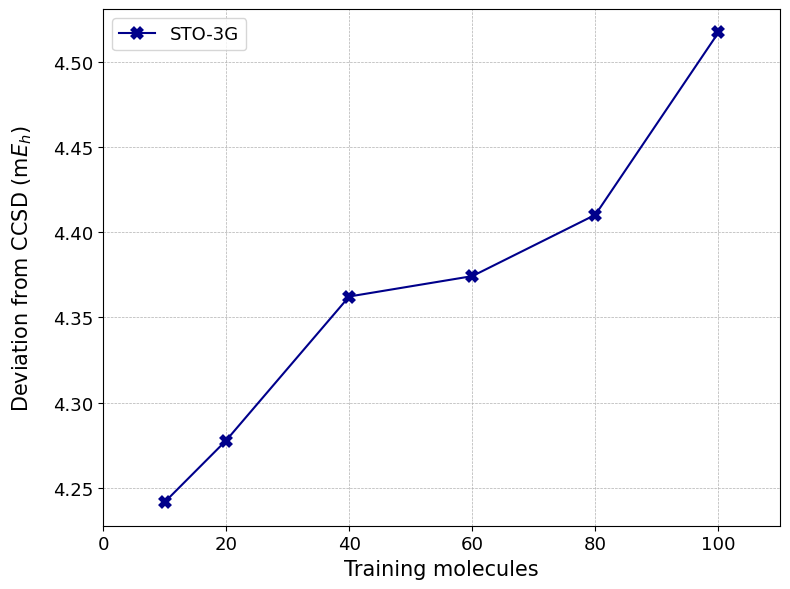

In [87]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(0, 110)
plt
plt.show()

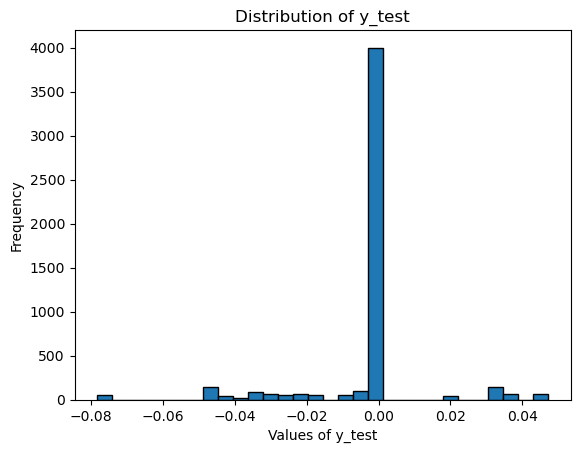

In [79]:
plt.hist(y_test, bins=30, edgecolor='black')
plt.xlabel("Values of y_test")
plt.ylabel("Frequency")
plt.title("Distribution of y_test")
plt.show()

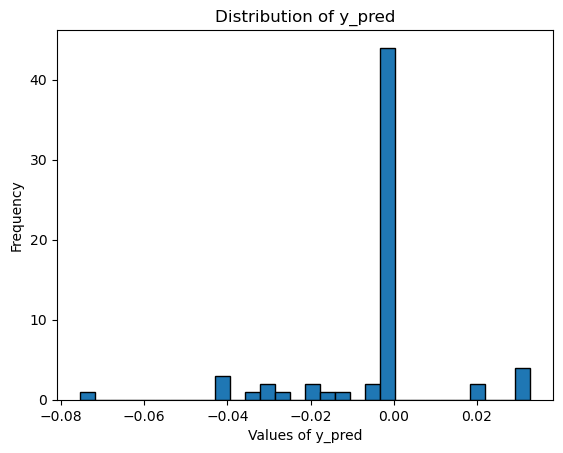

In [88]:
plt.hist(y_pred, bins=30, edgecolor='black')
plt.xlabel("Values of y_pred")
plt.ylabel("Frequency")
plt.title("Distribution of y_pred")
plt.show()

# Feature analysis

In [ ]:
################################################################################

In [23]:
basis = "STO-3G"
n = 100
data = joblib.load(f"water_out/{basis}_train_data_splits_{n}.pkl")

X_train = data["X_train"]
y_train = data["y_train"]

data = joblib.load(f"water_out/{basis}_test_data_splits.pkl")
X_test = data["X_test"]
y_test = data["y_test"]

In [25]:
# Clustering plots for the dataset
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [26]:
# Dimensionality reduction using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

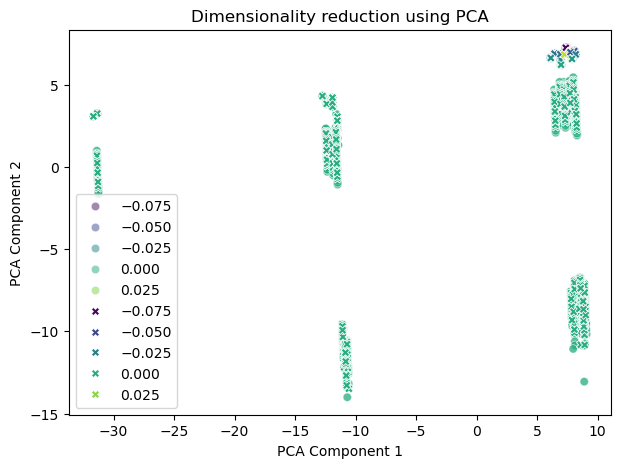

In [28]:
# Create the scatter plot with a continuous color range using "Spectral" palette
plt.figure(figsize=(7, 5))
scatter_train = sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train,  palette="viridis", alpha=0.5)
scatter_test = sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, palette="viridis", marker='X')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Dimensionality reduction using PCA')
plt.savefig("figs/pca.svg", format='svg', dpi=300)
plt.show()

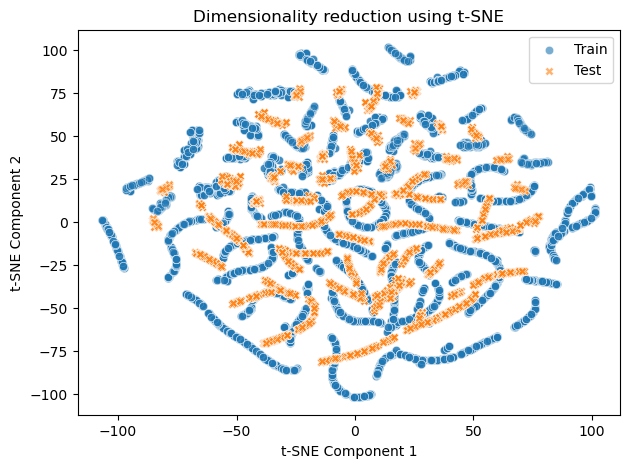

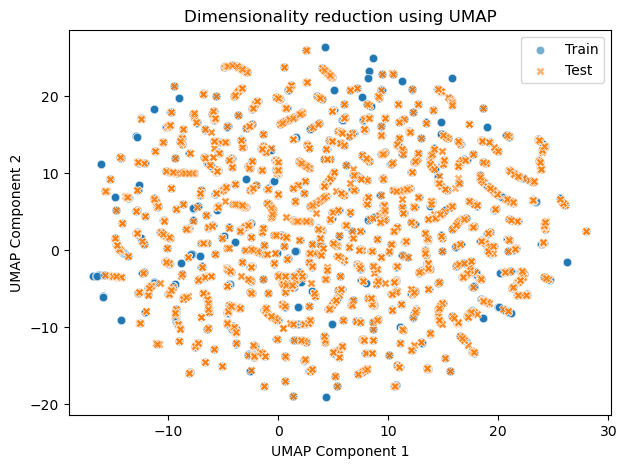

In [29]:
# Dimensionality reduction using t-SNE
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train)
X_test_tsne = tsne.fit_transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_tsne[:, 0], y=X_test_tsne[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Dimensionality reduction using t-SNE')
plt.legend()
plt.savefig("figs/tsne.svg", format='svg', dpi=300)
plt.show()

# Dimensionality reduction using UMAP
reducer = umap.UMAP()
X_train_umap = reducer.fit_transform(X_train)
X_test_umap = reducer.transform(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_umap[:, 0], y=X_train_umap[:, 1], label='Train', alpha=0.6)
sns.scatterplot(x=X_test_umap[:, 0], y=X_test_umap[:, 1], label='Test', alpha=0.6, marker='X')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('Dimensionality reduction using UMAP')
plt.legend()

plt.savefig("figs/umap.svg", format='svg', dpi=300)
plt.show()

In [30]:
X = np.concatenate([X_train, X_test], axis=0)
X_df = pd.DataFrame(X, columns=top5)

In [31]:
X_df

,doublecheck,t2start,t2mag,orbdiff,diag
0,3.103700e-02,-6.510431e-04,-3.127813,-41.657477,1.0
1,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
2,-2.236662e-05,5.106358e-07,-6.271769,-41.818623,0.0
3,2.192688e-02,-4.490889e-04,-3.282063,-41.979770,1.0
4,-5.962675e-03,2.397402e-04,-3.580287,-22.684461,1.0
...,...,...,...,...,...
14795,-2.629338e-16,1.573146e-16,-15.949694,-2.341749,1.0
14796,3.875622e-02,-2.443025e-02,-1.704970,-1.964768,1.0
14797,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0
14798,9.602268e-06,-6.713584e-06,-5.345279,-2.126437,0.0


In [32]:
y_full = np.concatenate([y_train, y_test])
X_df['t2'] = y_full

In [33]:
cols = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag', 't2']

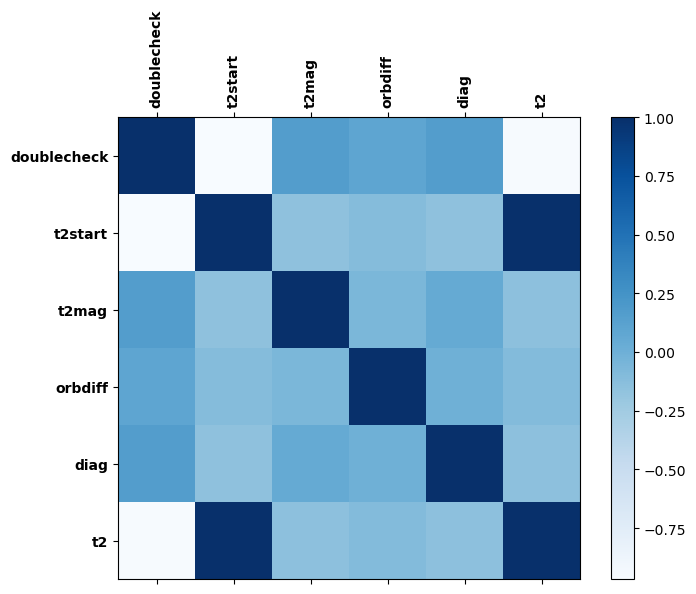

In [35]:
# Correlation matrix
corr = X_df.corr()

# Plot heatmap correctly
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap="Blues")

# Add colorbar
fig.colorbar(cax)

# Set ticks with feature names
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=10, weight='bold')
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=10, weight='bold')

plt.savefig("figs/corr_top5.svg", format='svg', dpi=300)
plt.show()

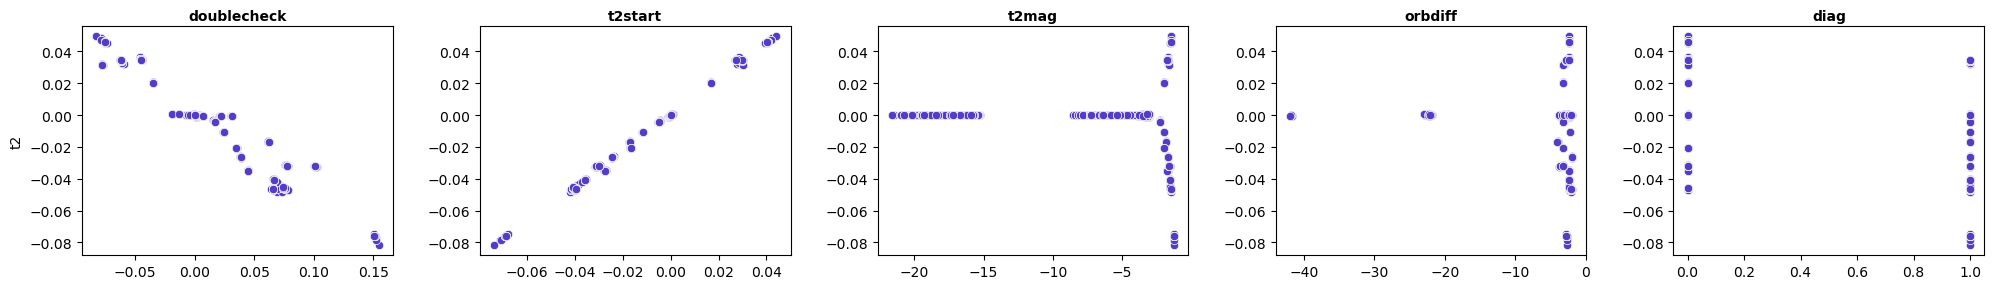

In [37]:
plot_df = X_df.copy()
target = 't2'

n_features = plot_df.shape[1] - 1  # exclude target
n_cols = 7
n_rows = (n_features - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()  # Flatten to simplify indexing

for i, col in enumerate(plot_df.columns):
    if col == target:
        continue
    sns.scatterplot(
        x=plot_df[col],
        y=plot_df[target],
        ax=axes[i],
        color="xkcd:blue with a hint of purple",
        legend=False
    )
    axes[i].set_xlabel(col, fontweight='bold')
    axes[i].xaxis.set_label_position('top')
    axes[i].set_ylabel(target if i % n_cols == 0 else '')

for j in range(len(plot_df.columns)-1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

plt.savefig("figs/corr_per_feature.svg", format='svg', dpi=300)
plt.show()

In [38]:
basis = "STO-3G"
n = 100
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_train_data_splits_{n}.pkl"
data = joblib.load(splits_fn)

X_train = data["X_train"]
y_train = data["y_train"]

splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/DDLUCJ/data/{basis}_test_data_splits.pkl"
data = joblib.load(splits_fn)
X_test = data["X_test"]
y_test = data["y_test"]

In [39]:
# SHAP feature importances
import shap
best_model = joblib.load('out/optimised_STO-3G_best_model_100.pkl')
tree_model = best_model.named_steps['xgb']

/home/max/miniconda3/envs/quantum/lib/python3.10/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/max/miniconda3/envs/quantum/lib/python3.10/pickle.py:1718: UserWarning: [13:30:37] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/home/

In [42]:
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

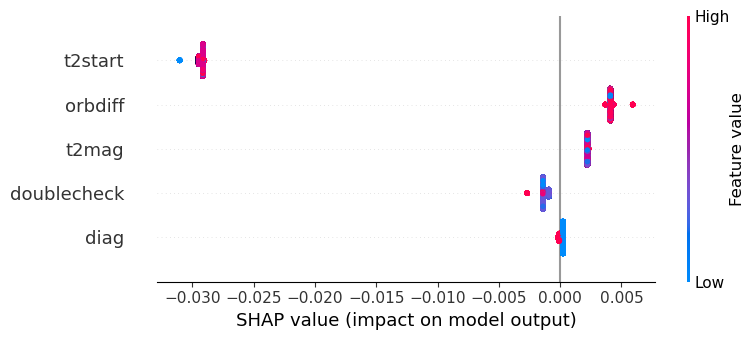

In [40]:
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, feature_names=top5)

In [ ]:
plt.figure(figsize=(18,10))

shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)

#plt.xticks(fontsize=10) 
#plt.yticks(fontsize=12)
plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=10)
plt.ylabel("Top 5 Features", fontsize=14, labelpad=40)

for patch in plt.gca().patches:
    patch.set_facecolor("skyblue") 

plt.show()

In [43]:
tree_model.feature_importances_        # XGBoost feature importance values match the SHAP analysis

array([0.12930758, 0.79009914, 0.02735599, 0.04682388, 0.0064134 ],
      dtype=float32)

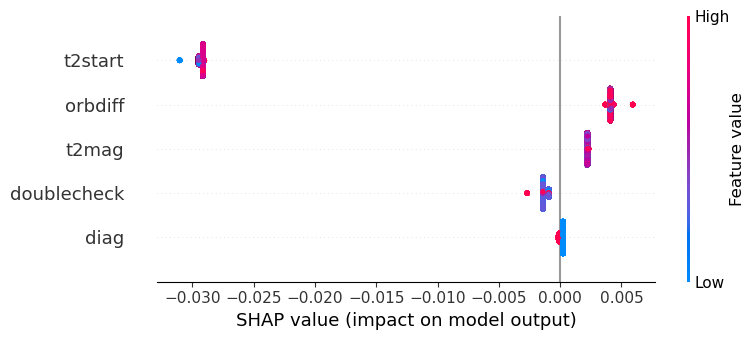

In [44]:
test_shap_values = explainer.shap_values(X_test)
shap.summary_plot(test_shap_values, X_test, feature_names=top5)

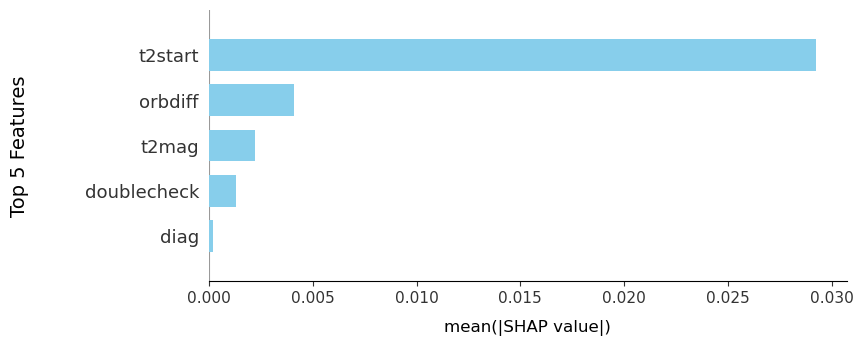

In [61]:
plt.figure(figsize=(18,10))

shap.summary_plot(
    shap_values, 
    X_train, 
    feature_names=top5,  
    plot_type='bar', 
    show=False
)

#plt.xticks(fontsize=10) 
#plt.yticks(fontsize=12)
plt.xlabel("mean(|SHAP value|)", fontsize=12, labelpad=10)
plt.ylabel("Top 5 Features", fontsize=14, labelpad=40)

for patch in plt.gca().patches:
    patch.set_facecolor("skyblue") 

plt.savefig("figs/shap_analysis.svg", format='svg', dpi=300)
plt.show()